# Chroma VectorDB


### 사용 사례
- RAG (Retrieval-Augmented Generation) 시스템
- 의미 기반 문서 검색
- 유사도 기반 추천 시스템
- 질문 답변 시스템


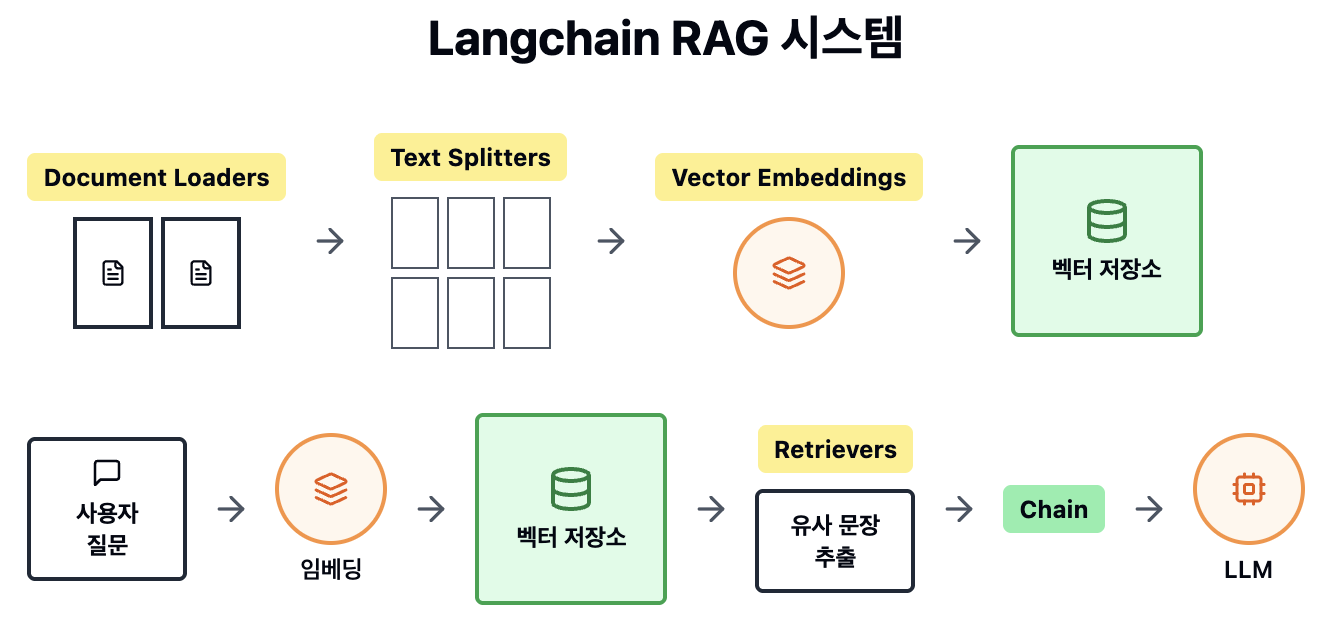

## 1. LangChain과 Chroma 통합

LangChain의 VectorStore 인터페이스를 사용하여 Chroma를 더 쉽게 사용하는 방법을 알아보겠습니다.


### Embedding Model

In [1]:
from langchain_ollama import OllamaEmbeddings

embeddings_ollama = OllamaEmbeddings(model="qwen3-embedding:0.6b")

### 텍스트 파일 로드

In [2]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("./data/rag-keywords.txt", encoding="utf-8")

documents = loader.load()
print(f"원본 문서 수: {len(documents)}")

원본 문서 수: 1


### 텍스트 분할

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200, # 청크 크기
    chunk_overlap=50 # 청크 중첩 크기
)
splits = text_splitter.split_documents(documents)

print(f"분할된 청크 수: {len(splits)}")
print(f"첫 번째 청크: {splits[0].page_content[:100]}...")


분할된 청크 수: 41
첫 번째 청크: Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을 넘어서 그 의미를 파악하여 관련된 결과를 반환하는 검색 방식입니다.
예시: 사용자가 "태...


### [VectorStore 생성](https://docs.langchain.com/oss/python/integrations/vectorstores/chroma)

In [4]:
from langchain_chroma import Chroma

file_vectorstore = Chroma.from_documents(
    documents=splits, # 문서 리스트
    embedding=embeddings_ollama, # 임베딩 함수
    collection_name="rag_keywords", # 컬렉션 이름
    persist_directory="./chroma_rag_keywords" # 영구 저장 경로
)

print("파일이 Chroma VectorStore에 저장되었습니다.")

파일이 Chroma VectorStore에 저장되었습니다.


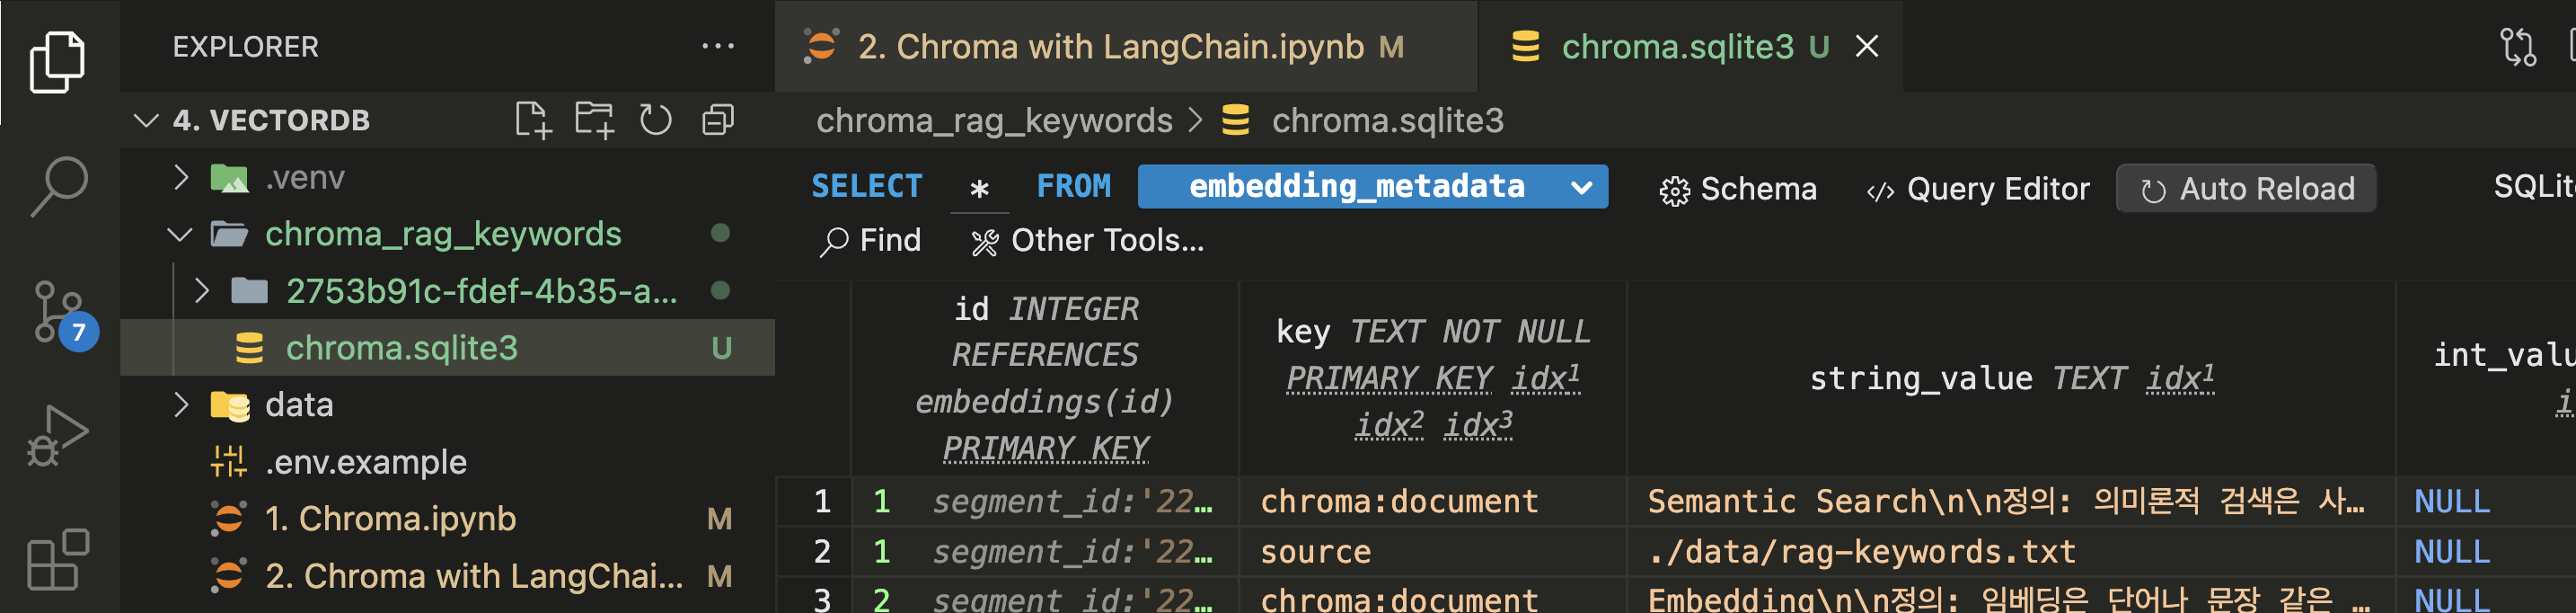

### 검색 테스트

In [5]:
test_queries = [
    "LLM란 무엇인가요?",
    "벡터 데이터베이스의 역할은?",
    "임베딩은 어떻게 생성되나요?"
]

for query in test_queries:
    print(f"\n질문: {query}")
    results = file_vectorstore.similarity_search(
        query,  # 질문 
        k=1     # 유사한 데이터(청크) 조회할 횟수 
    )
    print(f"답변: {results[0].page_content[:150]}...")
    print("="*50)



질문: LLM란 무엇인가요?
답변: 정의: LLM은 대규모의 텍스트 데이터로 훈련된 큰 규모의 언어 모델을 의미합니다. 이러한 모델은 다양한 자연어 이해 및 생성 작업에 사용됩니다.
예시: OpenAI의 GPT 시리즈는 대표적인 대규모 언어 모델입니다.
연관키워드: 자연어 처리, 딥러닝, 텍스트 생성

...

질문: 벡터 데이터베이스의 역할은?
답변: VectorStore

정의: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분석 작업에 사용됩니다.
예시: 단어 임베딩 벡터들을 데이터베이스에 저장하여 빠르게 접근할 수 있습니다.
연관키워드: 임베딩, 데이터베이스...

질문: 임베딩은 어떻게 생성되나요?
답변: Embedding

정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡터로 변환하는 과정입니다. 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다.
예시: "사과"라는 단어를 [0.65, -0.23, 0.17]과 같은 벡터로 표현합니다.
...


> similarity_search_with_score: 원본 거리 값 (낮을수록 유사)

In [6]:
# similarity_search_with_score 사용
query = "벡터 데이터베이스란 무엇인가요?"
results = file_vectorstore.similarity_search_with_score(query, k=3)

for doc, score in results:
    print(f"유사도 스코어: {score}")
    print(f"내용: {doc.page_content}")
    print("="*50)

유사도 스코어: 0.5614758133888245
내용: VectorStore

정의: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분석 작업에 사용됩니다.
예시: 단어 임베딩 벡터들을 데이터베이스에 저장하여 빠르게 접근할 수 있습니다.
연관키워드: 임베딩, 데이터베이스, 벡터화

SQL
유사도 스코어: 0.8135457634925842
내용: 연관키워드: 데이터베이스, 쿼리, 데이터 관리
유사도 스코어: 0.8968985080718994
내용: Tokenizer

정의: 토크나이저는 텍스트 데이터를 토큰으로 분할하는 도구입니다. 이는 자연어 처리에서 데이터를 전처리하는 데 사용됩니다.
예시: "I love programming."이라는 문장을 ["I", "love", "programming", "."]으로 분할합니다.
연관키워드: 토큰화, 자연어 처리, 구문 분석

VectorStore


> similarity_search_with_relevance_scores: 0~1로 정규화 (높을수록 유사)

In [7]:
# similarity_search_with_relevance_scores 사용 (0~1 정규화)
query = "벡터 데이터베이스란 무엇인가요?"
results = file_vectorstore.similarity_search_with_relevance_scores(query, k=3)

for doc, score in results:
    print(f"관련성 스코어: {score}")  # 0~1 사이 값
    print(f"내용: {doc.page_content}")
    print("="*50)

관련성 스코어: 0.6029766448805297
내용: VectorStore

정의: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분석 작업에 사용됩니다.
예시: 단어 임베딩 벡터들을 데이터베이스에 저장하여 빠르게 접근할 수 있습니다.
연관키워드: 임베딩, 데이터베이스, 벡터화

SQL
관련성 스코어: 0.4247362738288065
내용: 연관키워드: 데이터베이스, 쿼리, 데이터 관리
관련성 스코어: 0.3657969829062625
내용: Tokenizer

정의: 토크나이저는 텍스트 데이터를 토큰으로 분할하는 도구입니다. 이는 자연어 처리에서 데이터를 전처리하는 데 사용됩니다.
예시: "I love programming."이라는 문장을 ["I", "love", "programming", "."]으로 분할합니다.
연관키워드: 토큰화, 자연어 처리, 구문 분석

VectorStore


## 2. 고급 기능

Chroma의 고급 기능들을 알아보겠습니다.


### 메타데이터로 필터링 검색

In [8]:
filtered_docs = file_vectorstore.similarity_search(
    "벡터 데이터베이스", # 검색할 쿼리
    k=2, # 상위 2개 결과 반환
    filter={"source": "./data/rag-keywords.txt"}  # 특정 소스만 검색
)

print(f"\n필터링된 검색 결과: {len(filtered_docs)}개")



필터링된 검색 결과: 2개


In [9]:
for doc in filtered_docs:
    print(f"- {doc.page_content[:100]}...")

- VectorStore

정의: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분석 작업에 사용됩니다.
예시: 단어 임베딩 벡터...
- Tokenizer

정의: 토크나이저는 텍스트 데이터를 토큰으로 분할하는 도구입니다. 이는 자연어 처리에서 데이터를 전처리하는 데 사용됩니다.
예시: "I love programm...


### 최대 한계 관련성(Maximum Marginal Relevance, MMR)
- Maximum Marginal Relevance (MMR)는 정보 검색(Information Retrieval)이나 요약(Summarization) 등에서 중복을 최소화하면서(redundancy reduction) 동시에 관련성이 높은 정보(relevance maximization)를 선택하기 위해 사용되는 기법입니다.
- 쉽게 말해,
    > "가장 중요한 문서를 선택하되, 이미 선택한 문서와는 최대한 다르게 선택하자."

In [10]:
mmr_docs = file_vectorstore.max_marginal_relevance_search(
    "TF IDF 에 대하여 알려줘" # 검색할 쿼리
    , k=4, # 최대 4개 결과 반환
    fetch_k=10 # 처음에 10개 결과를 가져와서 MMR 적용
)

print(f"\nMMR 검색 결과: {len(mmr_docs)}개")



MMR 검색 결과: 4개


In [11]:
for doc in mmr_docs:
    print(f"- {doc.page_content[:100]}...")

- TF-IDF (Term Frequency-Inverse Document Frequency)...
- HuggingFace...
- 정의: FAISS는 페이스북에서 개발한 고속 유사성 검색 라이브러리로, 특히 대규모 벡터 집합에서 유사 벡터를 효과적으로 검색할 수 있도록 설계되었습니다.
예시: 수백만 개의 이미...
- 정의: GPT는 대규모의 데이터셋으로 사전 훈련된 생성적 언어 모델로, 다양한 텍스트 기반 작업에 활용됩니다. 이는 입력된 텍스트에 기반하여 자연스러운 언어를 생성할 수 있습니다....


### 컬렉션 정보 조회

In [12]:
collection_info = file_vectorstore._collection.get()

collection_info.keys()

dict_keys(['ids', 'embeddings', 'documents', 'uris', 'included', 'data', 'metadatas'])

In [13]:
print(f"metadatas 정보: {collection_info['metadatas'][0]}")
print(f"문서 수: {len(collection_info['ids'])}")

metadatas 정보: {'source': './data/rag-keywords.txt'}
문서 수: 41


### 특정 문서 업데이트

In [14]:
from langchain_community.docstore.document import Document

# 새 문서 생성
new_docs = [
    Document(page_content="새로운 문서 내용", metadata={"source": "updated"})
]

# LangChain Chroma에 문서 추가
ids = file_vectorstore.add_documents(new_docs)
print(f"저장된 아이디(들): {ids}")

저장된 아이디(들): ['0eac76fe-e7c8-48a5-b8a3-819d8ae6df95']


In [15]:
filtered_results = file_vectorstore.similarity_search(
    query="새로운 문서",  # 검색 쿼리
    k=3,
    filter={"source": "updated"}  # 메타데이터 필터
)


print("필터링된 검색 결과:")
for doc in filtered_results:
    print(f"- {doc}")

필터링된 검색 결과:
- page_content='새로운 문서 내용' metadata={'source': 'updated'}


### 문서 삭제

In [16]:
# LangChain Chroma 내부 Collection 직접 접근
collection = file_vectorstore._collection

# 메타데이터 조건으로 삭제
collection.delete(where={"source": "updated"})

In [17]:
filtered_results = file_vectorstore.similarity_search(
    query="새로운 문서",  # 검색 쿼리
    k=3,
    filter={"source": "updated"}  # 메타데이터 필터
)

print("필터링된 검색 결과:")
for doc in filtered_results:
    print(f"- {doc}")

필터링된 검색 결과:


### 컬렉션 통계

In [18]:
stats = file_vectorstore._collection.count()

print(f"현재 문서 수: {stats}")

현재 문서 수: 41
